In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.stats import sigma_clip
from scipy.stats import binned_statistic

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# So what we are going to do here is start with the Raw Data And Superimpose the Machine Learning work On Top of It #

<span style="color:grey">

### Grey Data ###

$
\mu_{\mathrm{obs}} = -2.5 \log_{10}(x_0) + \alpha x_1 - \beta c
$

- The residual values in the grey data block were corrected for color and stretch. 
- The sigma clipping and light curve quality flags will be done as part of this code.

The data that we see in grey is the *raw* data that has been cut for the paper-based
quality cuts and additionally sigma clipped in residual space using Astropy’s
`sigma_clip`:

1. Computes the mean and standard deviation of `y`
2. Flags any point satisfying $|y_i - \bar{y}| > 3\,\sigma_y$ as an outlier
3. Stops after one iteration (`maxiters = 1`)

</span>


<span style="color: blue">

### Blue Data ###

$
\mu_{\mathrm{obs}} = -2.5 \log_{10}(x_0)
$

- The residual values in the blue data block were left uncorrected for color and stretch. 

The data that we see in grey is the *raw* data that has been cut for the paper-based
quality cuts and additionally sigma clipped in residual space using Astropy’s
`sigma_clip`
(See grey for methodologies.)
</span>

776 SNe before paper-based quality cuts.
579 SNe after paper-based quality cuts.
776 SNe before paper-based quality cuts (df2).
579 SNe after paper-based quality cuts (df2).
579 SNe after LOGMSTAR cut.
579 SNe after LOGMSTAR cut (df2).


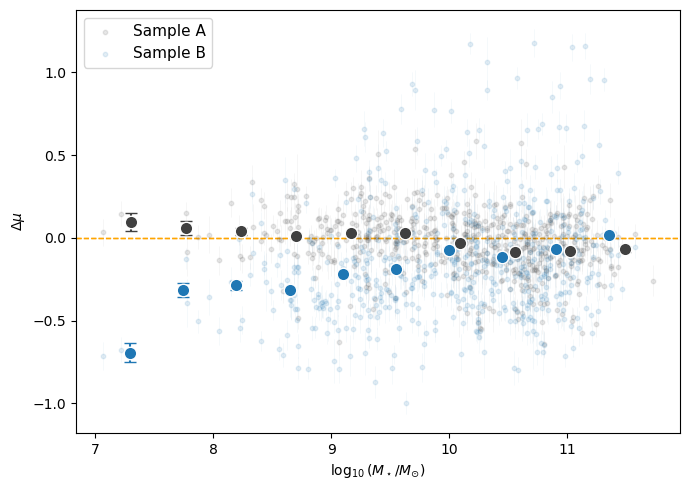

In [2]:
# =====================================================
# Read in FIRST dataset
# =====================================================

df = pd.read_csv(
    "ZTF_DESI_data/ZTF_resid_cent_hostprop_with_x1_c.csv"
)

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df), "SNe before paper-based quality cuts.")
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)]
print(len(df), "SNe after paper-based quality cuts.")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["SDSS_g_minus_r"] = df["ABSMAG01_SDSS_G"] - df["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all = df["sigma_mu_meas"]

# =====================================================
# Read in SECOND dataset (NEW)
# =====================================================

df2 = pd.read_csv(
    "ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv"
)

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df2), "SNe before paper-based quality cuts (df2).")
df2 = df2[(df2["lccoverage_flag"] == 1) & (df2["fitquality_flag"] == 1)]
print(len(df2), "SNe after paper-based quality cuts (df2).")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df2["SDSS_g_minus_r"] = df2["ABSMAG01_SDSS_G"] - df2["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all_2 = df2["sigma_mu_meas"]

nbins = 10

# Helper funciton that plots the scatter and error bars. 
# ax - matplotlib axis where the plots will be drawn. 
# mask - the mask that selects which rows to use. 
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.
# df_use - dataframe to plot
# yerr_use - error column associated with df_use
# color - color for this dataset

def scatter_with_errors(ax, mask, xcol, df_use, yerr_use, nbins=None, color="0.25", label=None):
    # Raw values
    x = df_use.loc[mask, xcol].values
    y = df_use.loc[mask, "residual_centered"].values
    yerr = yerr_use.loc[mask].values

    # --- sigma clipping in y (vertical axis) ---
    clipped = sigma_clip(y, sigma=3, maxiters=1)
    mask_clip = ~clipped.mask  # True = keep point

    # apply clipping to x, y, yerr
    x = x[mask_clip]
    y = y[mask_clip]
    yerr = yerr[mask_clip]

    # --- scatter cloud ---
    # Make the raw scatter a bit lighter so the binned trend stands out more.
    ax.scatter(
        x, y,
        alpha=0.12, s=10, color=color,
        zorder=1, rasterized=True, label=label
    )

    # --- individual error bars ---
    # Important to note that the way that this function works we will be drawing 
    # an error bar line from y - yerr to y + yerr. Where y_err = sigma_i
    # Make these lighter so they don't overpower the binned points.
    ax.errorbar(
        x, y, yerr=yerr,
        fmt="none",
        ecolor=color,
        elinewidth=0.4,
        alpha=0.08,
        zorder=1,
        capsize=0
    )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange", linewidth=1, zorder=0)

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here. 

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin. 
    # NOTE: here we want to just count the number of points in each bin on the 
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the 
    # value and simply choose "count" as our statistics option. 
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on. 
    # Bin centers are just calcualted as the middle points between one bin edge and another.
    
    # NOTE: use nbins instead of hard-coding bins=10
    if nbins is None:
        nbins = 10

    _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins) 
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals. 
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array. 
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # We end up finding data and errro associated
        # with the number of bin that we are in. 
        y_bin = y[in_bin]
        err_bin = yerr[in_bin]
    
        # inverse-variance weights
        w = 1.0 / (err_bin**2)

        # Avoid divide-by-zero issues if a bin is empty
        if np.sum(in_bin) == 0:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue
    
        # weighted mean
        y_mean = np.sum(w * y_bin) / np.sum(w)
    
        # propagated error on the mean
        err_mean = 1.0 / np.sqrt(np.sum(w))
    
        binned_y.append(y_mean)
        binned_yerr.append(err_mean)

    # Plot only the binned points (no connecting trend line)
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)

    ax.errorbar(
        bin_centers[ok],
        binned_y[ok],
        yerr=binned_yerr[ok],
        fmt="o",
        color=color,
        markersize=9,          # Larger binned markers
        capsize=4,             # Slightly smaller caps than 10 for a cleaner look
        markeredgewidth=1.0,
        markeredgecolor="white",
        zorder=5 # Keeps the data looking on top
    )

# **************************************
# --------------------------------------
# Single plot: LOGMSTAR only
# --------------------------------------
# **************************************

fig, ax = plt.subplots(figsize=(7, 5))

# --------------------------------------
# LOGMSTAR
# --------------------------------------

# finite values mask
mask_logm = np.isfinite(df["LOGMSTAR"])
print(np.sum(mask_logm), "SNe after LOGMSTAR cut.")

mask_logm_2 = np.isfinite(df2["LOGMSTAR"])
print(np.sum(mask_logm_2), "SNe after LOGMSTAR cut (df2).")

# Use helper function (FIRST dataset)
scatter_with_errors(
    ax,
    mask_logm,
    "LOGMSTAR",
    df,
    yerr_all,
    nbins,
    color="0.25",
    label="Sample A"
)

# Use helper function (SECOND dataset)
scatter_with_errors(
    ax,
    mask_logm_2,
    "LOGMSTAR",
    df2,
    yerr_all_2,
    nbins,
    color="tab:blue",
    label="Sample B"
)

# Axis labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# Cosmetics
# --------------------------------------

ax.legend(
    loc="best",
    frameon=True,
    fontsize=11
)
fig.tight_layout()
plt.show()

# Now Lets Do SLR with the Random Forest Algorythm Where we Trie to Recover Either of the above trends #

776 SNe before paper-based quality cuts.
579 SNe after paper-based quality cuts.
776 SNe before paper-based quality cuts (df2).
579 SNe after paper-based quality cuts (df2).
579 SNe after LOGMSTAR cut (raw full sample).
116 SNe after LOGMSTAR cut (test set).


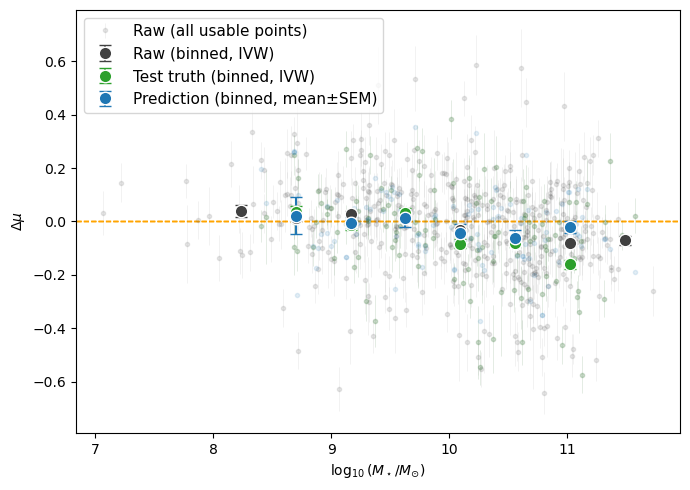

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.stats import sigma_clip
from scipy.stats import binned_statistic

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =====================================================
# Read in FIRST dataset
# =====================================================

df = pd.read_csv(
    "ZTF_DESI_data/ZTF_resid_cent_hostprop_with_x1_c.csv"
)

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df), "SNe before paper-based quality cuts.")
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)]
print(len(df), "SNe after paper-based quality cuts.")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["SDSS_g_minus_r"] = df["ABSMAG01_SDSS_G"] - df["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all = df["sigma_mu_meas"]


# =====================================================
# Read in SECOND dataset (NEW)
# =====================================================

df2 = pd.read_csv(
    "ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv"
)

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df2), "SNe before paper-based quality cuts (df2).")
df2 = df2[(df2["lccoverage_flag"] == 1) & (df2["fitquality_flag"] == 1)]
print(len(df2), "SNe after paper-based quality cuts (df2).")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df2["SDSS_g_minus_r"] = df2["ABSMAG01_SDSS_G"] - df2["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all_2 = df2["sigma_mu_meas"]

# Helper funciton that plots the scatter and error bars.
# ax - matplotlib axis where the plots will be drawn.
# mask - the mask that selects which rows to use.
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.
# df_use - dataframe to plot
# yerr_use - error column associated with df_use
# color - color for this dataset
#
# NOTE (NEW): This function now optionally plots binned points using externally-supplied bin_edges,
# so we can FORCE the test-truth and prediction to use the exact same binning.

def scatter_with_errors(
    ax,
    mask,
    xcol,
    df_use,
    yerr_use,
    nbins=None,
    color="0.25",
    label=None,
    # NEW knobs:
    ycol="residual_centered",
    bin_edges=None,
    bin_label=None,
    # For binned behavior:
    binned_mode="ivw",   # "ivw" for inverse-variance weighted mean (uses yerr); "mean_sem" for mean+SEM (ignores yerr)
    min_per_bin=8
):
    # Raw values
    x = df_use.loc[mask, xcol]
    y = df_use.loc[mask, ycol]
    yerr = yerr_use.loc[mask] if yerr_use is not None else None

    # --------------------------------------
    # Signma clipping the residual values. 
    # --------------------------------------

    clipped = sigma_clip(y, sigma=3, maxiters=1)
    mask_clip = ~clipped.mask  # True = keep point

    # apply clipping to x, y, yerr
    x = x[mask_clip]
    y = y[mask_clip]
    if yerr is not None:
        yerr = yerr[mask_clip]

    # --------------------------------------
    # Scatter Cloud With Error bars
    # --------------------------------------

    # Draw the raw points as markers with their associated measurement uncertainties.
    ax.errorbar(
        x, y,
        yerr=yerr,
        fmt="o",              # markers ON
        markersize=3,         # small so they don't fight the binned points
        color=color,
        ecolor=color,
        elinewidth=0.4,
        alpha=0.12,
        zorder=1,
        capsize=0,
        rasterized=True,
        label=label
    )

    # --------------------------------------
    # Orange horizontal reference line
    # --------------------------------------
    ax.axhline(0, linestyle="--", color="orange", linewidth=1, zorder=0)

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here.

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin.
    # NOTE: here we want to just count the number of points in each bin on the
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the
    # value and simply choose "count" as our statistics option.
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on.
    # Bin centers are just calcualted as the middle points between one bin edge and another.


    # If bin_edges is provided, we FORCE these exact edges (for truth vs prediction comparisons).
    if bin_edges is None:
        _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins)
    else:
        _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=bin_edges)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals.
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array.
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # Require some minimum occupancy so you don't get goofy single-point bins.
        if np.sum(in_bin) < min_per_bin:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue

        # We end up finding data and errro associated
        # with the number of bin that we are in.
        y_bin = y[in_bin]

        if binned_mode == "ivw":
            # inverse-variance weights
            if yerr is None:
                binned_y.append(np.nan)
                binned_yerr.append(np.nan)
                continue

            err_bin = yerr[in_bin]
            w = 1.0 / (err_bin**2)

            # weighted mean
            y_mean = np.sum(w * y_bin) / np.sum(w)

            # propagated error on the mean
            err_mean = 1.0 / np.sqrt(np.sum(w))

        elif binned_mode == "mean_sem":
            # plain mean + SEM (useful for predictions)
            y_mean = np.mean(y_bin)
            err_mean = np.std(y_bin, ddof=1) / np.sqrt(np.sum(in_bin))

        else:
            raise ValueError("binned_mode must be 'ivw' or 'mean_sem'")

        binned_y.append(y_mean)
        binned_yerr.append(err_mean)

    # Plot only the binned points (no connecting trend line)
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)

    ax.errorbar(
        bin_centers,
        binned_y,
        yerr=binned_yerr,
        fmt="o",
        color=color,
        markersize=9,          # Larger binned markers
        capsize=4,             # Slightly smaller caps than 10 for a cleaner look
        markeredgewidth=1.0,
        markeredgecolor="white",
        zorder=5,              # Keeps the data looking on top
        label=bin_label
    )

    # Return edges so the caller can reuse them for other series
    return bin_edges

# =====================================================
# -----------------------------
# 2) Choose target we're trying to predict + features that will be used in training
# -----------------------------
# =====================================================
target_col = "residual_centered"

feature_cols = [
    "LOGMSTAR",
    # "SFR",
    # "VDISP",
    # "DN4000",
    # "SDSS_g_minus_r",
    # "AGE",
    # "x1",
    # "c"
]

# Building table that ends up selecting only the feature_cols
# and target_col from the data frame we read "df"
df_model = df[feature_cols + [target_col]].copy()

# Separating data into train and test splits here.
X = df_model[feature_cols]
y = df_model[target_col]

# -----------------------------
# 4) Build + train model pipeline
# -----------------------------
#  Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Create a Random Forest Regressor object
rf_regressor = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1
)

#  Train the regressor on the training data
rf_regressor.fit(X_train, y_train)

#  Make predictions on the test set
y_pred_test = rf_regressor.predict(X_test)

# # -----------------------------
# # 5) Basic regression metrics
# # -----------------------------
# rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
# mae  = mean_absolute_error(y_test, y_pred_test)
# r2   = r2_score(y_test, y_pred_test)

# print(f"N_train = {len(X_train)}  N_test = {len(X_test)}")
# print(f"Test RMSE: {rmse:.4f}")
# print(f"Test  MAE: {mae:.4f}")
# print(f"Test   R2: {r2:.4f}")


# **************************************
# --------------------------------------
# Single plot: LOGMSTAR only
#   - Raw (df) with sigma-clip + binned (IVW)
#   - Test truth with sigma-clip + binned (IVW)
#   - Predictions with SAME sigma-clip mask + binned (mean±SEM)
# **************************************
feature_name = "LOGMSTAR"

fig, ax = plt.subplots(figsize=(7, 5))

# --------------------------------------
# LOGMSTAR
# --------------------------------------

# finite values mask (RAW FULL SAMPLE)
mask_logm = np.isfinite(df[feature_name])
print(np.sum(mask_logm), "SNe after LOGMSTAR cut (raw full sample).")

# Build a test-set dataframe that includes x, y_true, y_pred, and yerr for binning/plotting
df_test_plot = pd.DataFrame({
    feature_name: X_test[feature_name].to_numpy(),
    "y_true": np.asarray(y_test),
    "y_pred": np.asarray(y_pred_test),
    # attach measurement errors for these exact test rows via index alignment
    "sigma_mu_meas": yerr_all.loc[y_test.index].to_numpy()
}, index=y_test.index)

# finite values mask (TEST SET)
mask_test = np.isfinite(df_test_plot[feature_name]) & np.isfinite(df_test_plot["y_true"]) & np.isfinite(df_test_plot["y_pred"]) & np.isfinite(df_test_plot["sigma_mu_meas"])
print(np.sum(mask_test), "SNe after LOGMSTAR cut (test set).")

# Use helper function (RAW FULL SAMPLE): this returns bin_edges
bin_edges = scatter_with_errors(
    ax,
    mask_logm,
    feature_name,
    df,
    yerr_all,
    nbins,
    color="0.25",
    label="Raw (all usable points)",
    # (binned)
    ycol=target_col,
    bin_edges=None,  # let it compute its own equal-width edges
    bin_label="Raw (binned, IVW)",
    binned_mode="ivw",
    min_per_bin=8
)

# Use helper function (TEST TRUTH): FORCE the same edges as predictions will use
_ = scatter_with_errors(
    ax,
    mask_test,
    feature_name,
    df_test_plot,
    df_test_plot["sigma_mu_meas"],
    nbins,
    color="tab:green",
    label=None,  # don't clutter legend with points unless you want it
    # (plot test truth points lightly)
    ycol="y_true",
    bin_edges=bin_edges,   # FORCE SAME EDGES
    bin_label="Test truth (binned, IVW)",
    binned_mode="ivw",
    min_per_bin=8
)

# Use helper function (PREDICTIONS): SAME edges, but mean+SEM (no measurement yerr for preds)
_ = scatter_with_errors(
    ax,
    mask_test,
    feature_name,
    df_test_plot,
    yerr_use=None,          # predictions don't have sigma_mu; we use SEM instead
    nbins=nbins,
    color="tab:blue",
    label=None,
    # (plot prediction points? usually unnecessary; set draw_points=True if you want the cloud)
    ycol="y_pred",
    bin_edges=bin_edges,    # FORCE SAME EDGES
    bin_label="Prediction (binned, mean±SEM)",
    binned_mode="mean_sem",
    min_per_bin=8
)

# Axis labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# Cosmetics
# --------------------------------------
ax.legend(
    loc="best",
    frameon=True,
    fontsize=11
)
fig.tight_layout()
plt.show()

0.194626840510302 Standard Deviation of True Residuals
0.1484729634726049 Standard Deviation of Predicted Residuals


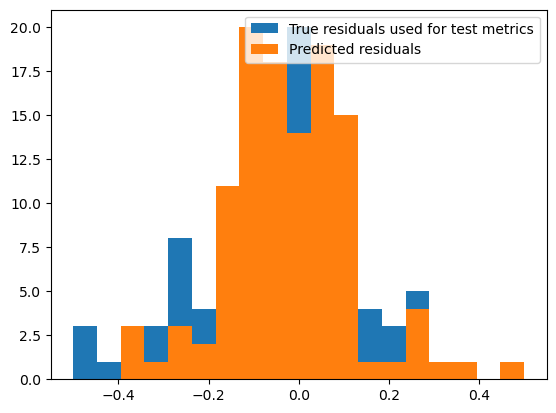

In [4]:
# plt.hist(df_model["residual_centered"], label="Full dataset")
# plt.hist(y_train, label="Residuals Used to Train")
bins = np.linspace(-0.5, 0.5, 20)
plt.hist(y_test, label="True residuals used for test metrics", bins = bins)
plt.hist(y_pred_test, label="Predicted residuals", bins = bins)
print(str(np.std(y_test)) + " Standard Deviation of True Residuals")
print(str(np.std(y_pred_test)) + " Standard Deviation of Predicted Residuals")
plt.legend()

776 SNe before paper-based quality cuts.
579 SNe after paper-based quality cuts.
776 SNe before paper-based quality cuts (df2).
579 SNe after paper-based quality cuts (df2).
579 SNe after LOGMSTAR cut (raw full sample).
116 SNe after LOGMSTAR cut (test set).


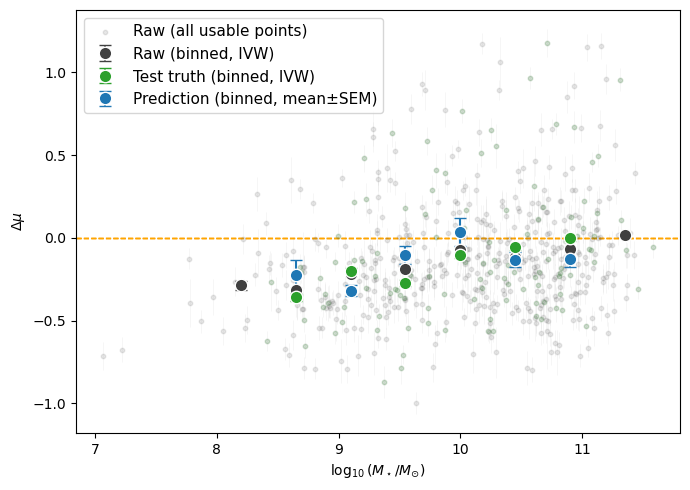

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.stats import sigma_clip
from scipy.stats import binned_statistic

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =====================================================
# Read in FIRST dataset
# =====================================================

df = pd.read_csv(
    "ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv"
)

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df), "SNe before paper-based quality cuts.")
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)]
print(len(df), "SNe after paper-based quality cuts.")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["SDSS_g_minus_r"] = df["ABSMAG01_SDSS_G"] - df["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all = df["sigma_mu_meas"]


# =====================================================
# Read in SECOND dataset (NEW)
# =====================================================

df2 = pd.read_csv(
    "ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv"
)

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df2), "SNe before paper-based quality cuts (df2).")
df2 = df2[(df2["lccoverage_flag"] == 1) & (df2["fitquality_flag"] == 1)]
print(len(df2), "SNe after paper-based quality cuts (df2).")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df2["SDSS_g_minus_r"] = df2["ABSMAG01_SDSS_G"] - df2["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all_2 = df2["sigma_mu_meas"]

nbins = 10


# Helper funciton that plots the scatter and error bars.
# ax - matplotlib axis where the plots will be drawn.
# mask - the mask that selects which rows to use.
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.
# df_use - dataframe to plot
# yerr_use - error column associated with df_use
# color - color for this dataset
#
# NOTE (NEW): This function now optionally plots binned points using externally-supplied bin_edges,
# so we can FORCE the test-truth and prediction to use the exact same binning.

def scatter_with_errors(
    ax,
    mask,
    xcol,
    df_use,
    yerr_use,
    nbins=None,
    color="0.25",
    label=None,
    # NEW knobs:
    ycol="residual_centered",
    draw_points=True,
    draw_errorbars=True,
    draw_binned=True,
    bin_edges=None,
    bin_label=None,
    # For binned behavior:
    binned_mode="ivw",   # "ivw" for inverse-variance weighted mean (uses yerr); "mean_sem" for mean+SEM (ignores yerr)
    min_per_bin=8
):
    # Raw values
    x = df_use.loc[mask, xcol].values
    y = df_use.loc[mask, ycol].values
    yerr = yerr_use.loc[mask].values if yerr_use is not None else None

    # --- sigma clipping in y (vertical axis) ---
    clipped = sigma_clip(y, sigma=3, maxiters=1)
    mask_clip = ~clipped.mask  # True = keep point

    # apply clipping to x, y, yerr
    x = x[mask_clip]
    y = y[mask_clip]
    if yerr is not None:
        yerr = yerr[mask_clip]

    # --- scatter cloud ---
    # Make the raw scatter a bit lighter so the binned trend stands out more.
    if draw_points:
        ax.scatter(
            x, y,
            alpha=0.12, s=10, color=color,
            zorder=1, rasterized=True, label=label
        )

    # --- individual error bars ---
    # Important to note that the way that this function works we will be drawing
    # an error bar line from y - yerr to y + yerr. Where y_err = sigma_i
    # Make these lighter so they don't overpower the binned points.
    if draw_errorbars and (yerr is not None):
        ax.errorbar(
            x, y, yerr=yerr,
            fmt="none",
            ecolor=color,
            elinewidth=0.4,
            alpha=0.08,
            zorder=1,
            capsize=0
        )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange", linewidth=1, zorder=0)

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here.

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin.
    # NOTE: here we want to just count the number of points in each bin on the
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the
    # value and simply choose "count" as our statistics option.
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on.
    # Bin centers are just calcualted as the middle points between one bin edge and another.

    if not draw_binned:
        return None

    # NOTE: use nbins instead of hard-coding bins=10
    if nbins is None:
        nbins = 10

    # If bin_edges is provided, we FORCE these exact edges (for truth vs prediction comparisons).
    if bin_edges is None:
        _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins)
    else:
        _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=bin_edges)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals.
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array.
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # Require some minimum occupancy so you don't get goofy single-point bins.
        if np.sum(in_bin) < min_per_bin:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue

        # We end up finding data and errro associated
        # with the number of bin that we are in.
        y_bin = y[in_bin]

        if binned_mode == "ivw":
            # inverse-variance weights
            if yerr is None:
                binned_y.append(np.nan)
                binned_yerr.append(np.nan)
                continue

            err_bin = yerr[in_bin]
            w = 1.0 / (err_bin**2)

            # weighted mean
            y_mean = np.sum(w * y_bin) / np.sum(w)

            # propagated error on the mean
            err_mean = 1.0 / np.sqrt(np.sum(w))

        elif binned_mode == "mean_sem":
            # plain mean + SEM (useful for predictions)
            y_mean = np.mean(y_bin)
            err_mean = np.std(y_bin, ddof=1) / np.sqrt(np.sum(in_bin))

        else:
            raise ValueError("binned_mode must be 'ivw' or 'mean_sem'")

        binned_y.append(y_mean)
        binned_yerr.append(err_mean)

    # Plot only the binned points (no connecting trend line)
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)

    ax.errorbar(
        bin_centers[ok],
        binned_y[ok],
        yerr=binned_yerr[ok],
        fmt="o",
        color=color,
        markersize=9,          # Larger binned markers
        capsize=4,             # Slightly smaller caps than 10 for a cleaner look
        markeredgewidth=1.0,
        markeredgecolor="white",
        zorder=5,              # Keeps the data looking on top
        label=bin_label
    )

    # Return edges so the caller can reuse them for other series
    return bin_edges


# =====================================================
# -----------------------------
# 2) Choose target we're trying to predict + features that will be used in training
# -----------------------------
# =====================================================
target_col = "residual_centered"

feature_cols = [
    "LOGMSTAR",
    "SFR",
    "VDISP",
    "DN4000",
    "SDSS_g_minus_r",
    "AGE",
    "x1",
    "c"
]

# Building table that ends up selecting only the feature_cols
# and target_col from the data frame we read "df"
df_model = df[feature_cols + [target_col]].copy()

# Separating data into train and test splits here.
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# 4) Build + train model pipeline
# -----------------------------
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        # min_samples_leaf=20,   # trend-smoothing knob
    ))
])

model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

# # -----------------------------
# # 5) Basic regression metrics
# # -----------------------------
# rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
# mae  = mean_absolute_error(y_test, y_pred_test)
# r2   = r2_score(y_test, y_pred_test)

# print(f"N_train = {len(X_train)}  N_test = {len(X_test)}")
# print(f"Test RMSE: {rmse:.4f}")
# print(f"Test  MAE: {mae:.4f}")
# print(f"Test   R2: {r2:.4f}")


# **************************************
# --------------------------------------
# Single plot: LOGMSTAR only
#   - Raw (df) with sigma-clip + binned (IVW)
#   - Test truth with sigma-clip + binned (IVW)
#   - Predictions with SAME sigma-clip mask + binned (mean±SEM)
# **************************************
feature_name = "LOGMSTAR"

fig, ax = plt.subplots(figsize=(7, 5))

# --------------------------------------
# LOGMSTAR
# --------------------------------------

# finite values mask (RAW FULL SAMPLE)
mask_logm = np.isfinite(df[feature_name])
print(np.sum(mask_logm), "SNe after LOGMSTAR cut (raw full sample).")

# Build a test-set dataframe that includes x, y_true, y_pred, and yerr for binning/plotting
df_test_plot = pd.DataFrame({
    feature_name: X_test[feature_name].to_numpy(),
    "y_true": np.asarray(y_test),
    "y_pred": np.asarray(y_pred_test),
    # attach measurement errors for these exact test rows via index alignment
    "sigma_mu_meas": yerr_all.loc[y_test.index].to_numpy()
}, index=y_test.index)

# finite values mask (TEST SET)
mask_test = np.isfinite(df_test_plot[feature_name]) & np.isfinite(df_test_plot["y_true"]) & np.isfinite(df_test_plot["y_pred"]) & np.isfinite(df_test_plot["sigma_mu_meas"])
print(np.sum(mask_test), "SNe after LOGMSTAR cut (test set).")

# Use helper function (RAW FULL SAMPLE): this returns bin_edges
bin_edges = scatter_with_errors(
    ax,
    mask_logm,
    feature_name,
    df,
    yerr_all,
    nbins,
    color="0.25",
    label="Raw (all usable points)",
    # (binned)
    ycol=target_col,
    draw_points=True,
    draw_errorbars=True,
    draw_binned=True,
    bin_edges=None,  # let it compute its own equal-width edges
    bin_label="Raw (binned, IVW)",
    binned_mode="ivw",
    min_per_bin=8
)

# Use helper function (TEST TRUTH): FORCE the same edges as predictions will use
_ = scatter_with_errors(
    ax,
    mask_test,
    feature_name,
    df_test_plot,
    df_test_plot["sigma_mu_meas"],
    nbins,
    color="tab:green",
    label=None,  # don't clutter legend with points unless you want it
    # (plot test truth points lightly)
    ycol="y_true",
    draw_points=True,
    draw_errorbars=False,  # usually too busy; flip to True if you want them
    draw_binned=True,
    bin_edges=bin_edges,   # FORCE SAME EDGES
    bin_label="Test truth (binned, IVW)",
    binned_mode="ivw",
    min_per_bin=8
)

# Use helper function (PREDICTIONS): SAME edges, but mean+SEM (no measurement yerr for preds)
_ = scatter_with_errors(
    ax,
    mask_test,
    feature_name,
    df_test_plot,
    yerr_use=None,          # predictions don't have sigma_mu; we use SEM instead
    nbins=nbins,
    color="tab:blue",
    label=None,
    # (plot prediction points? usually unnecessary; set draw_points=True if you want the cloud)
    ycol="y_pred",
    draw_points=False,
    draw_errorbars=False,
    draw_binned=True,
    bin_edges=bin_edges,    # FORCE SAME EDGES
    bin_label="Prediction (binned, mean±SEM)",
    binned_mode="mean_sem",
    min_per_bin=8
)

# Axis labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# Cosmetics
# --------------------------------------
ax.legend(
    loc="best",
    frameon=True,
    fontsize=11
)
fig.tight_layout()
plt.show()

0.46483181246832944 Standard Deviation of True Residuals
0.33661123222916217 Standard Deviation of Predicted Residuals


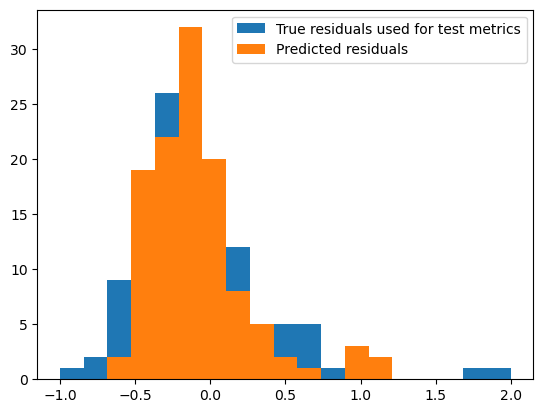

In [6]:
# plt.hist(df_model["residual_centered"], label="Full dataset")
# plt.hist(y_train, label="Residuals Used to Train")
bins = np.linspace(-1, 2, 20)
plt.hist(y_test, label="True residuals used for test metrics", bins = bins)
plt.hist(y_pred_test, label="Predicted residuals", bins = bins)
print(str(np.std(y_test)) + " Standard Deviation of True Residuals")
print(str(np.std(y_pred_test)) + " Standard Deviation of Predicted Residuals")
plt.legend()